findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

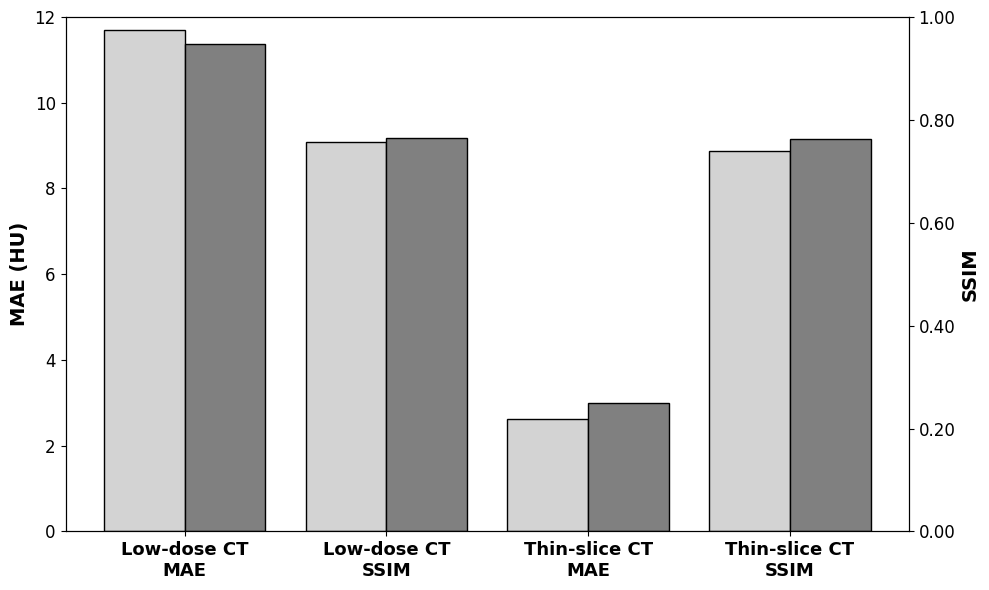

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------- 1. 读取并预处理数据 --------------------------
low_dose_CT_result = pd.read_excel('/host/d/projects/denoising/results/mayo_results.xlsx').iloc[0:3]
thin_slice_CT_result = pd.read_excel('/host/d/projects/denoising/results/brainCT_results.xlsx').iloc[0:16]

# 提取指标并计算均值
lowdose_mae_avg = np.mean(low_dose_CT_result['mae_unsupervised_avg20'].values)
lowdose_mae_dist = np.mean(low_dose_CT_result['mae_distilled'].values)
lowdose_ssim_avg = np.mean(low_dose_CT_result['ssim_unsupervised_avg20'].values)
lowdose_ssim_dist = np.mean(low_dose_CT_result['ssim_distilled'].values)

thinslice_mae_avg = np.mean(thin_slice_CT_result['mae_unsupervised_avg20'].values)
thinslice_mae_dist = np.mean(thin_slice_CT_result['mae_distilled'].values)
thinslice_ssim_avg = np.mean(thin_slice_CT_result['ssim_unsupervised_avg20'].values)
thinslice_ssim_dist = np.mean(thin_slice_CT_result['ssim_distilled'].values)


# -------------------------- 2. 数据缩放（SSIM匹配MAE可视化尺度：乘以12） --------------------------
scale_factor = 12  # MAE范围~0-12，SSIM*12后与MAE同尺度展示
# 分组数据（每组：Avg20左 + Distilled右）
groups = [
    "Low-dose CT\nMAE",
    "Low-dose CT\nSSIM",
    "Thin-slice CT\nMAE",
    "Thin-slice CT\nSSIM"
]
# 原始数据（MAE直接用，SSIM缩放后可视化）
avg20_vis_data = [
    lowdose_mae_avg, 
    lowdose_ssim_avg * scale_factor, 
    thinslice_mae_avg, 
    thinslice_ssim_avg * scale_factor
]
distilled_vis_data = [
    lowdose_mae_dist, 
    lowdose_ssim_dist * scale_factor, 
    thinslice_mae_dist, 
    thinslice_ssim_dist * scale_factor
]
# 真实SSIM（用于右轴刻度）
ssim_true_data = [lowdose_ssim_avg, lowdose_ssim_dist, thinslice_ssim_avg, thinslice_ssim_dist]


# -------------------------- 3. 配置图表 --------------------------
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax1 = plt.subplots(figsize=(10, 6))
bar_width = 0.4
x_pos = np.arange(len(groups))


# -------------------------- 4. 绘制柱状图（灰度+填充样式） --------------------------
# Avg20：浅灰色、无填充
bars_avg = ax1.bar(
    x_pos - bar_width/2,
    avg20_vis_data,
    bar_width,
    color='#D3D3D3',  # 浅灰色
    edgecolor='black',
    linewidth=1
)
# Distilled：深灰色、斜线填充
bars_dist = ax1.bar(
    x_pos + bar_width/2,
    distilled_vis_data,
    bar_width,
    color='#808080',  # 深灰色
    edgecolor='black',
    linewidth=1,
    # hatch='//'  # 斜线填充
)


# -------------------------- 5. 配置双轴（左轴：缩放后值；右轴：真实SSIM） --------------------------
# 左轴：对应MAE真实值 + 缩放后SSIM（标注MAE单位）
ax1.set_ylabel('MAE (HU)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups, fontsize=13, fontweight='bold')
ax1.set_ylim(bottom=0, top=12)  # 匹配MAE最大范围

# 右轴：真实SSIM（0-1）
ax2 = ax1.twinx()
ax2.set_ylabel('SSIM', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 1)  # SSIM真实范围
# 同步右轴刻度与缩放后数据（确保SSIM真实值对应可视化高度）
ax2.set_yticks(np.linspace(0, 1, 6))
ax2.set_yticklabels([f'{v:.2f}' for v in np.linspace(0, 1, 6)])


# -------------------------- 6. 布局调整（去掉标题、图例等） --------------------------
plt.tight_layout()


# -------------------------- 7. 保存高清图表 --------------------------
# plt.savefig('mae_ssim_final_comparison.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.savefig('/host/d/projects/denoising/pictures/ablation_distill.pdf',  bbox_inches='tight')